In [1]:
## import libraries
import h5py
import numpy as np
from PIL import Image
import glob
import time
import matplotlib.pyplot as plt
import logging
from cil.utilities.display import show2D
from cil.recon import FDK
import os
import imageio
from cil.framework import AcquisitionGeometry, ImageGeometry
from cil.plugins.astra import FBP, ProjectionOperator
from cil.utilities.jupyter import islicer
from cil.optimisation.algorithms import PDHG, FISTA, ISTA, GD, SPDHG, LADMM, SIRT
from cil.optimisation.utilities import RandomSampling
from cil.optimisation.functions import L2NormSquared, TotalVariation, BlockFunction, IndicatorBox, ZeroFunction, OperatorCompositionFunction, SmoothMixedL21Norm, LeastSquares, SGFunction, SAGAFunction, SVRGFunction, LSVRGFunction
from cil.optimisation.operators import BlockOperator, GradientOperator
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.processors import TransmissionAbsorptionConverter
import zarr
import dask
from cil.optimisation.utilities import MetricsDiagnostics, RSE, Sensitivity


In [2]:
sino1 = zarr.load("../../A4I_2023/Stochastic/NiPd_spent_01_microct_rings_removed.zarr")

In [3]:
vertical , num_angles, horizontal = sino1.shape

In [4]:
angles_list = np.linspace(0, np.pi, num_angles)
ag = AcquisitionGeometry.create_Parallel3D().\
        set_panel([horizontal,vertical]).\
        set_angles(angles_list, angle_unit="radian").\
        set_labels(['vertical','angle','horizontal'])
ig = ag.get_ImageGeometry()
ag.shape

(700, 800, 695)

In [5]:
sino_cil = ag.allocate()
sino_cil.fill(sino1)

In [6]:
data2D = sino_cil.get_slice(vertical=350)
ag2D = data2D.geometry
ig2D = ag2D.get_ImageGeometry()
fbp_recon = FBP(ig2D, ag2D)(data2D)

initial = fbp_recon   
A = ProjectionOperator(ig2D, ag2D, device="gpu")

In [7]:
sirt = SIRT(ig2D.allocate(), A, data2D, lower=0., max_iteration=500, update_objective_interval=50)
sirt.run(verbose=1)

     Iter   Max Iter  Time(s)/Iter            Objective
        0        500         0.000          8.17946e+02
       50        500         0.062          2.80119e+01
      100        500         0.062          2.59983e+01
      150        500         0.064          2.52092e+01
      200        500         0.067          2.47147e+01
      250        500         0.068          2.43580e+01
      300        500         0.069          2.40826e+01
      350        500         0.070          2.38611e+01
      400        500         0.070          2.36784e+01
      450        500         0.070          2.35247e+01
      500        500         0.071          2.33934e+01
-------------------------------------------------------
Stop criterion has been reached.



In [8]:
cb = MetricsDiagnostics(reference_image = sirt.solution, verbose=1, metrics_dict={'rse':RSE}) 

In [9]:
sirt1 = SIRT(ig2D.allocate(), A, data2D, lower=0., max_iteration=100, update_objective_interval=1)
sirt1.run(verbose=1, callback=[cb])

     Iter   Max Iter  Time(s)/Iter            Objective                 rse
        0        100         0.000          8.17946e+02         9.53633e-02
        1        100         0.092          1.12608e+02         7.74251e-02
        2        100         0.080          8.31847e+01         7.33948e-02
        3        100         0.079          6.70394e+01         7.06605e-02
        4        100         0.078          5.75683e+01         6.86699e-02
        5        100         0.077          5.16232e+01         6.71231e-02
        6        100         0.077          4.76477e+01         6.58542e-02
        7        100         0.076          4.48434e+01         6.47683e-02
        8        100         0.076          4.27577e+01         6.38094e-02
        9        100         0.076          4.11330e+01         6.29436e-02
       10        100         0.076          3.98200e+01         6.21490e-02
       11        100         0.075          3.87285e+01         6.14113e-02
       12   

In [10]:
M = 1./A.direct(A.domain_geometry().allocate(value=1.0)) 
f = LeastSquares(A=A, b=data2D, c=0.5, weight=M)
step_size = 1.
preconditioner = Sensitivity(A)
g = IndicatorBox(lower=0.)

def update_objective(self):
    # SIRT computes |Ax_{k} - b|
    # ISTA with weighted LeastSquares computes the objective included the weight, so we remove the weight
    self.loss.append(0.5*(self.f.A.direct(self.x_old) - self.f.b).squared_norm())
    
ISTA.update_objective = update_objective

precond_pwls = ISTA(ig2D.allocate(), f=f,  g=g, preconditioner = preconditioner,
               max_iteration=100, update_objective_interval=1, step_size = step_size)       

precond_pwls.run(verbose=1, callback=[cb])

     Iter   Max Iter  Time(s)/Iter            Objective                 rse
        0        100         0.000          8.17946e+02         9.53633e-02
        1        100         0.073          1.12608e+02         7.74251e-02
        2        100         0.072          8.31847e+01         7.33948e-02
        3        100         0.071          6.70394e+01         7.06605e-02
        4        100         0.071          5.75683e+01         6.86699e-02
        5        100         0.072          5.16232e+01         6.71231e-02
        6        100         0.072          4.76477e+01         6.58542e-02
        7        100         0.071          4.48434e+01         6.47683e-02
        8        100         0.072          4.27577e+01         6.38094e-02
        9        100         0.072          4.11330e+01         6.29436e-02
       10        100         0.071          3.98200e+01         6.21490e-02
       11        100         0.071          3.87285e+01         6.14113e-02
       12   

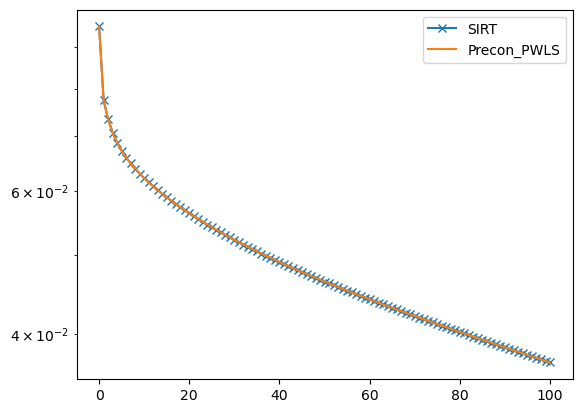

In [11]:
plt.figure()
plt.semilogy(sirt1.rse, label="SIRT", marker="x")
plt.semilogy(precond_pwls.rse, label="Precon_PWLS")
plt.legend()
plt.show()

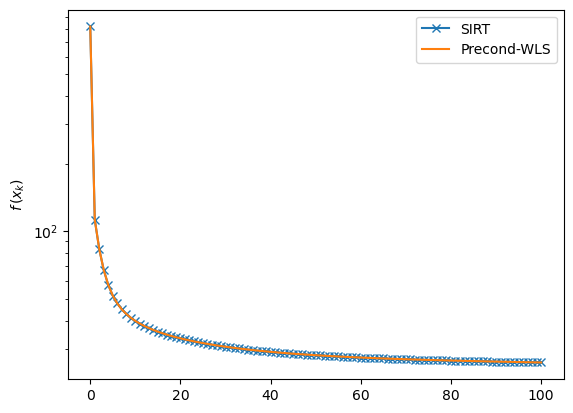

In [12]:
plt.figure()
plt.semilogy(sirt1.objective, label="SIRT", marker="x")
plt.semilogy(precond_pwls.objective, label="Precond-WLS")
plt.legend()
plt.ylabel(r"$f\,(x_{k})$")
plt.show()

In [13]:
np.testing.assert_allclose(sirt1.solution.array, precond_pwls.solution.array, atol=1e-4)